# 01. Tối ưu không ràng buộc — Genetic Algorithm tìm Global Optimum

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import sympy
from IPython.display import Markdown, display

In [2]:
def genetic_algorithm_unconstrained(
    objective,
    bounds,

    population_size=500,
    generations=100,

    crossover_rate=0.9,
    mutation_rate=0.15,
    mutation_scale=0.08,

    elite_size=2,
    tournament_size=3,

    seed=42,
):
    rng = np.random.default_rng(seed)

    bounds = np.asarray(bounds, dtype=float)

    lower = bounds[:, 0]
    upper = bounds[:, 1]

    variable_range = upper - lower
    n_variables = len(bounds)

    def clip(pop):
        return np.clip(pop, lower, upper)

    # --------------------------------------------------------
    # Initial population
    # --------------------------------------------------------

    population = clip(
        rng.uniform(lower, upper, size=(population_size, n_variables))
    )

    def evaluate(pop):
        return np.array([objective(individual) for individual in pop])

    # --------------------------------------------------------
    # Tournament selection (theo thứ hạng fitness)
    # --------------------------------------------------------

    def tournament_selection(rank):

        indices = rng.integers(0, population_size, size=tournament_size)

        best_index = indices[np.argmin(rank[indices])]

        return population[best_index].copy()

    # --------------------------------------------------------
    # Blend crossover
    # --------------------------------------------------------

    def crossover(parent1, parent2):

        if rng.random() > crossover_rate:
            return parent1.copy(), parent2.copy()

        alpha = rng.uniform(-0.25, 1.25, size=n_variables)

        child1 = alpha * parent1 + (1 - alpha) * parent2
        child2 = alpha * parent2 + (1 - alpha) * parent1

        return child1, child2

    # --------------------------------------------------------
    # Gaussian mutation
    # --------------------------------------------------------

    def mutate(child):

        mutation_mask = rng.random(n_variables) < mutation_rate

        if np.any(mutation_mask):
            child[mutation_mask] += rng.normal(
                loc=0,
                scale=mutation_scale * variable_range[mutation_mask],
            )

        return child

    # --------------------------------------------------------
    # Evolution
    # --------------------------------------------------------

    history = []

    start_time = time.perf_counter()

    fitness = evaluate(population)

    best_index = int(np.argmin(fitness))
    best_solution = population[best_index].copy()
    best_fitness = fitness[best_index]

    for generation in range(generations):

        order = np.argsort(fitness)

        rank = np.empty(population_size, dtype=np.int64)
        rank[order] = np.arange(population_size)

        current_best = int(np.argmin(fitness))
        if fitness[current_best] < best_fitness:
            best_fitness = fitness[current_best]
            best_solution = population[current_best].copy()

        history.append(best_fitness)

        # Elitism
        new_population = [
            population[i].copy()
            for i in order[:elite_size]
        ]

        # Sinh thế hệ tiếp theo
        while len(new_population) < population_size:

            parent1 = tournament_selection(rank)
            parent2 = tournament_selection(rank)

            child1, child2 = crossover(parent1, parent2)

            new_population.append(mutate(child1))

            if len(new_population) < population_size:
                new_population.append(mutate(child2))

        population = clip(np.asarray(new_population))
        fitness = evaluate(population)

    current_best = int(np.argmin(fitness))
    if fitness[current_best] < best_fitness:
        best_fitness = fitness[current_best]
        best_solution = population[current_best].copy()

    elapsed_time = time.perf_counter() - start_time

    # Thế hệ sớm nhất mà nghiệm tốt nhất (best_fitness cuối cùng) đã đạt
    # được — chỉ là một chỉ số báo cáo, KHÔNG dừng vòng lặp sớm.
    generations_run = int(np.argmin(history)) + 1

    return {
        "x": best_solution,
        "fun": best_fitness,
        "time": elapsed_time,
        "history": history,
        "generations": generations,
        "generations_run": generations_run,
        "seed": seed,
    }

In [3]:
def make_objective(expr, variables):
    objective_raw = sympy.lambdify(variables, expr, modules="numpy")

    def objective(v):
        try:
            value = float(np.asarray(objective_raw(*v)).reshape(()))
            if np.isfinite(value):
                return value
        except Exception:
            pass
        return np.inf

    return objective

In [4]:
# ------------------------------------------------------------------
# Hiển thị dạng ký hiệu toán học (LaTeX)
# ------------------------------------------------------------------

def _num(value, digits=10):
    if not np.isfinite(value):
        return r"\infty" if value > 0 else r"-\infty"
    if value != 0 and (abs(value) >= 1e6 or abs(value) < 1e-4):
        mantissa, exponent = f"{value:.4e}".split("e")
        return mantissa + r" \times 10^{" + str(int(exponent)) + "}"
    return f"{value:.{digits}f}"

In [5]:
def _num_bound(value):
    text = _num(value, 4)
    if "." in text and "times" not in text:
        text = text.rstrip("0").rstrip(".")
    return text

In [6]:
def show_problem(objective_expr, variables, bounds):
    bien = ", ".join(sympy.latex(v) for v in variables)
    mien = ", \\ ".join(
        f"{_num_bound(b[0])} \\le {sympy.latex(v)} \\le {_num_bound(b[1])}"
        for v, b in zip(variables, bounds)
    )
    display(Markdown(
        "$$\n\\underset{" + bien + r"}{\text{minimize}} \quad f\left("
        + bien + r"\right) = " + sympy.latex(objective_expr) + "\n$$\n\n"
        + "Miền tìm kiếm: $" + mien + "$"
    ))

In [7]:
def show_result(result, variables):
    bien = "(" + ", ".join(sympy.latex(v) for v in variables) + ")"
    toado = "(" + ", \\ ".join(_num(x) for x in result["x"]) + ")"

    display(Markdown(
        "| Thời gian hội tụ (s) | Số thế hệ thỏa mãn | $f^{*}$ | $" + bien + "$ |\n"
        "|---|---|---|---|\n"
        "| $" + _num(result["time"], 6) + "$ | $" + str(result["generations_run"])
        + "$ | $" + _num(result["fun"]) + "$ | $" + toado + "$ |"
    ))

In [8]:
def show_convergence(result, name):
    SURFACE, INK, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

    history = result["history"]
    generation = np.arange(1, len(history) + 1)
    converged_at = result["generations_run"]

    fig, ax = plt.subplots(figsize=(7.5, 4.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    ax.plot(generation, history, color="#2a78d6", linewidth=2, label="$f$ tốt nhất")
    ax.axvline(
        converged_at, color=INK_MUTED, linewidth=1.4, linestyle="--",
        label=f"Hội tụ ở thế hệ {converged_at}",
    )

    ax.set_xlim(0, result["generations"])
    ax.set_xticks(np.arange(0, result["generations"] + 1, 5))
    ax.set_xlabel("Thế hệ", color=INK_MUTED, fontsize=11)
    ax.set_ylabel("$f$ tốt nhất", color=INK_MUTED, fontsize=11)
    ax.set_title(f"{name} — giá trị tối ưu qua các thế hệ",
                 color=INK, fontsize=12, pad=10)

    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(GRID)

    legend = ax.legend(frameon=False, fontsize=10)
    for text in legend.get_texts():
        text.set_color(INK_MUTED)

    fig.tight_layout()
    plt.show()

In [9]:
x, y = sympy.symbols("x y")
variables_xy = [x, y]

# Tham số GA dùng cho toàn bộ benchmark bên dưới.
POPULATION_SIZE = 500
GENERATIONS = 50
SEED = 42

# Năm hàm benchmark kinh điển, đặt thủ công (không qua parser) —
# miền tìm kiếm lấy theo giá trị chuẩn thường dùng trong tài liệu.
BENCHMARKS = {
    "Easom": {
        "expr": (
            -sympy.cos(x) * sympy.cos(y)
            * sympy.exp(-((x - sympy.pi) ** 2 + (y - sympy.pi) ** 2))
        ),
        "bounds": [(-100.0, 100.0), (-100.0, 100.0)],
        "optimum": r"f(\pi, \pi) = -1",
    },
    "Rastrigin": {
        "expr": (
            20 + x**2 - 10 * sympy.cos(2 * sympy.pi * x)
            + y**2 - 10 * sympy.cos(2 * sympy.pi * y)
        ),
        "bounds": [(-5.12, 5.12), (-5.12, 5.12)],
        "optimum": "f(0, 0) = 0",
    },
    "Rosenbrock": {
        "expr": (1 - x) ** 2 + 100 * (y - x**2) ** 2,
        "bounds": [(-5.0, 10.0), (-5.0, 10.0)],
        "optimum": "f(1, 1) = 0",
    },
    "Ackley": {
        "expr": (
            -20 * sympy.exp(-0.2 * sympy.sqrt(0.5 * (x**2 + y**2)))
            - sympy.exp(0.5 * (sympy.cos(2 * sympy.pi * x) + sympy.cos(2 * sympy.pi * y)))
            + 20 + sympy.E
        ),
        "bounds": [(-32.768, 32.768), (-32.768, 32.768)],
        "optimum": "f(0, 0) = 0",
    },
    "Schwefel": {
        "expr": (
            418.9829 * 2
            - x * sympy.sin(sympy.sqrt(sympy.Abs(x)))
            - y * sympy.sin(sympy.sqrt(sympy.Abs(y)))
        ),
        "bounds": [(-500.0, 500.0), (-500.0, 500.0)],
        "optimum": r"f(420.9687, 420.9687) \approx 0",
    },
}

In [10]:
def run_benchmark(name):
    spec = BENCHMARKS[name]

    expr = spec["expr"]
    bounds = spec["bounds"]

    objective = make_objective(expr, variables_xy)

    display(Markdown(f"### {name} — nghiệm đúng: ${spec['optimum']}$"))
    show_problem(expr, variables_xy, bounds)

    result = genetic_algorithm_unconstrained(
        objective, bounds,
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        seed=SEED,
    )

    show_result(result, variables_xy)
    show_convergence(result, name)

    return result

## Easom

### Easom — nghiệm đúng: $f(\pi, \pi) = -1$

$$
\underset{x, y}{\text{minimize}} \quad f\left(x, y\right) = - e^{- \left(x - \pi\right)^{2} - \left(y - \pi\right)^{2}} \cos{\left(x \right)} \cos{\left(y \right)}
$$

Miền tìm kiếm: $-100 \le x \le 100, \ -100 \le y \le 100$

| Thời gian hội tụ (s) | Số thế hệ thỏa mãn | $f^{*}$ | $(x, y)$ |
|---|---|---|---|
| $0.713547$ | $48$ | $-1.0000000000$ | $(3.1415926582, \ 3.1415926572)$ |

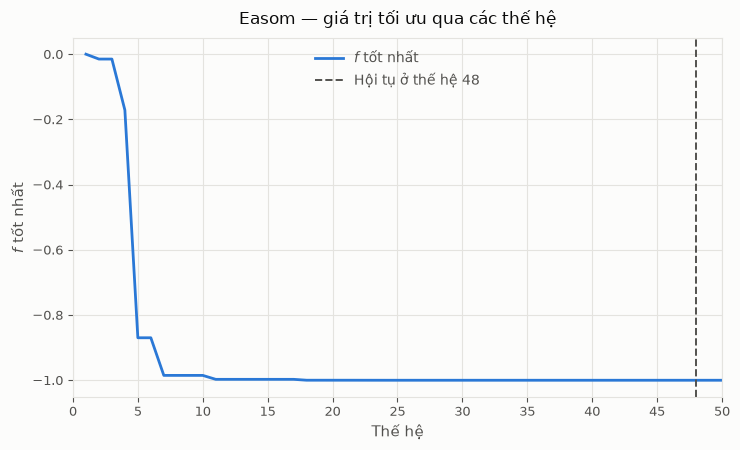

In [11]:
result_easom = run_benchmark("Easom")

## Rastrigin

### Rastrigin — nghiệm đúng: $f(0, 0) = 0$

$$
\underset{x, y}{\text{minimize}} \quad f\left(x, y\right) = x^{2} + y^{2} - 10 \cos{\left(2 \pi x \right)} - 10 \cos{\left(2 \pi y \right)} + 20
$$

Miền tìm kiếm: $-5.12 \le x \le 5.12, \ -5.12 \le y \le 5.12$

| Thời gian hội tụ (s) | Số thế hệ thỏa mãn | $f^{*}$ | $(x, y)$ |
|---|---|---|---|
| $0.771011$ | $45$ | $0.0000000000$ | $(8.0012 \times 10^{-10}, \ -2.1100 \times 10^{-9})$ |

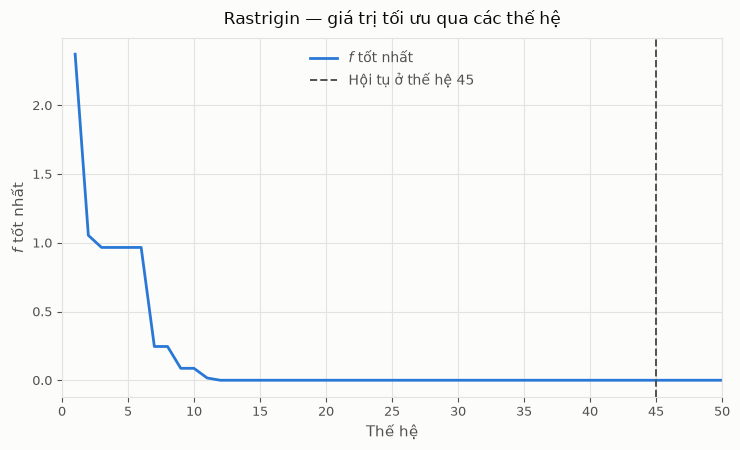

In [12]:
result_rastrigin = run_benchmark("Rastrigin")

## Rosenbrock

### Rosenbrock — nghiệm đúng: $f(1, 1) = 0$

$$
\underset{x, y}{\text{minimize}} \quad f\left(x, y\right) = \left(1 - x\right)^{2} + 100 \left(- x^{2} + y\right)^{2}
$$

Miền tìm kiếm: $-5 \le x \le 10, \ -5 \le y \le 10$

| Thời gian hội tụ (s) | Số thế hệ thỏa mãn | $f^{*}$ | $(x, y)$ |
|---|---|---|---|
| $0.702522$ | $11$ | $0.0009051359$ | $(1.0088392929, \ 1.0148809532)$ |

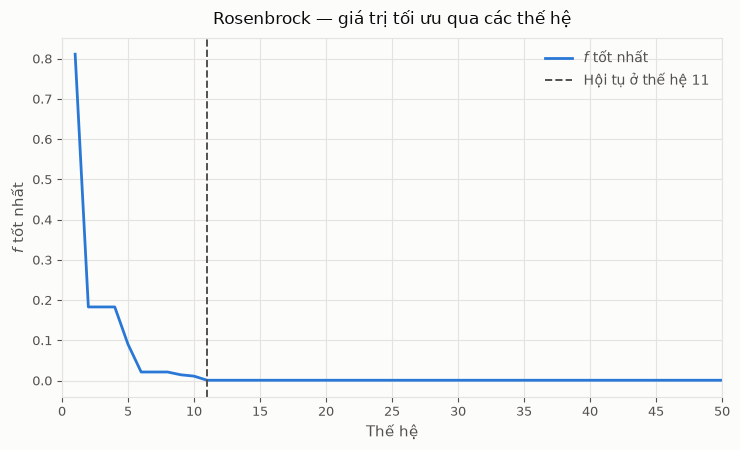

In [13]:
result_rosenbrock = run_benchmark("Rosenbrock")

## Ackley

### Ackley — nghiệm đúng: $f(0, 0) = 0$

$$
\underset{x, y}{\text{minimize}} \quad f\left(x, y\right) = - e^{0.5 \cos{\left(2 \pi x \right)} + 0.5 \cos{\left(2 \pi y \right)}} + e + 20 - 20 e^{- 0.2 \sqrt{0.5 x^{2} + 0.5 y^{2}}}
$$

Miền tìm kiếm: $-32.768 \le x \le 32.768, \ -32.768 \le y \le 32.768$

| Thời gian hội tụ (s) | Số thế hệ thỏa mãn | $f^{*}$ | $(x, y)$ |
|---|---|---|---|
| $0.753205$ | $50$ | $3.3440 \times 10^{-10}$ | $(-7.5481 \times 10^{-11}, \ -9.0998 \times 10^{-11})$ |

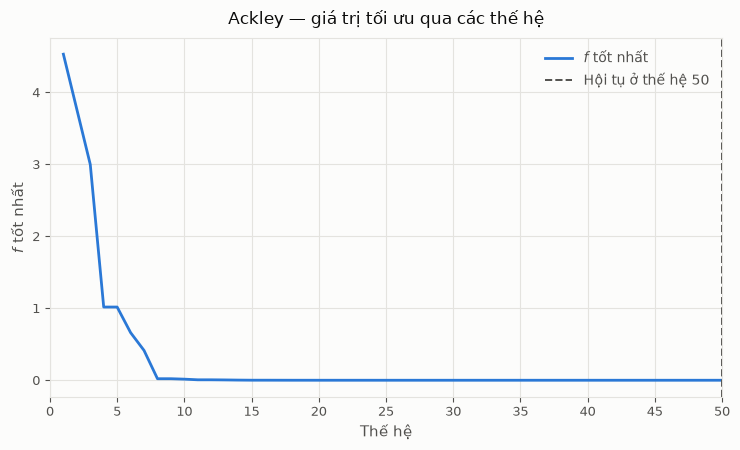

In [14]:
result_ackley = run_benchmark("Ackley")

## Schwefel

### Schwefel — nghiệm đúng: $f(420.9687, 420.9687) \approx 0$

$$
\underset{x, y}{\text{minimize}} \quad f\left(x, y\right) = - x \sin{\left(\sqrt{\left|{x}\right|} \right)} - y \sin{\left(\sqrt{\left|{y}\right|} \right)} + 837.9658
$$

Miền tìm kiếm: $-500 \le x \le 500, \ -500 \le y \le 500$

| Thời gian hội tụ (s) | Số thế hệ thỏa mãn | $f^{*}$ | $(x, y)$ |
|---|---|---|---|
| $0.728747$ | $47$ | $2.5455 \times 10^{-5}$ | $(420.9687463412, \ 420.9687463714)$ |

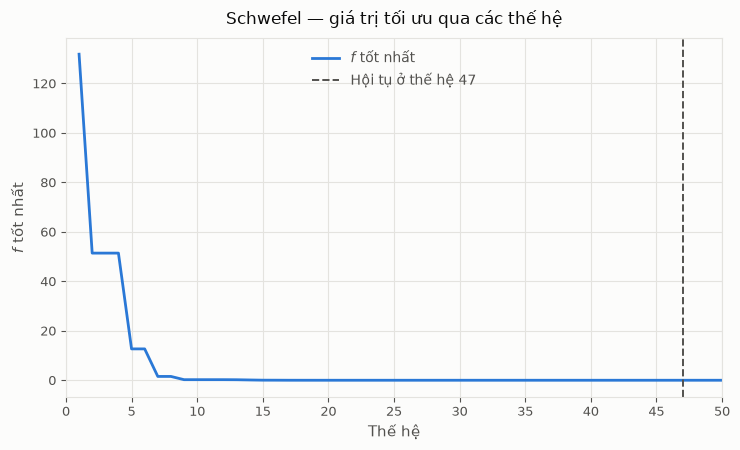

In [15]:
result_schwefel = run_benchmark("Schwefel")